# Exploratory Data Analysis (EDA)
This notebook performs comprehensive EDA on the HCMC Air Quality dataset for the target variable PM2.5 and meteorological features

In [ ]:
library(tidyverse)
library(lubridate)
library(openair)   
library(gridExtra) 
library(forecast)  

# 1. Load Data
Loading the preprocessed dataset data/processed/hcmc_merged_cleaned.csv and setting the datetime index.

In [ ]:
df <- read.csv("C:/Users/bao03/qbao_R/IS403_HCMC_Air_Quality/data/processed/hcmc_merged_cleaned.csv")
# Chuyển cột thời gian về định dạng chuẩn R
df$datetime_local <- as.POSIXct(df$datetime_local, format="%Y-%m-%d %H:%M:%S")

                  

Train Dataset shape (using only top 60% dates): (6441, 12)

In [ ]:

# Danh sách các biến cần phân tích theo yêu cầu
all_features <- c("pm25", "pm1", "temperature_2m", "relative_humidity_2m", 
                  "wind_speed_10m", "wind_direction_10m", "boundary_layer_height", 
                  "surface_pressure", "precipitation")

# 2. Univariate Analysis
Analyzing the distribution and identifying potential outliers for each individual variable.

In [ ]:
print("--- Đang thực hiện Univariate EDA ---")
plot_list <- list()

for (col in all_features) {
  # Biểu đồ phân phối (Histogram)
p1 <- ggplot(df, aes(x = .data[[col]])) +
  geom_histogram(fill = "#008080", color = "white", bins = 30) + # Mã Hex của màu Teal
  labs(title = paste("Distribution of", col)) + theme_minimal()
  
  # Biểu đồ ngoại lai (Boxplot)
  p2 <- ggplot(df, aes(y = .data[[col]])) +
    geom_boxplot(fill = "coral") +
    labs(title = paste("Outliers of", col)) + theme_minimal()
  
  plot_list[[length(plot_list) + 1]] <- p1
  plot_list[[length(plot_list) + 1]] <- p2
}

# Hiển thị lưới biểu đồ (Mỗi trang hiện 3 biến - 6 hình)
do.call(grid.arrange, c(plot_list[1:6], ncol = 2))


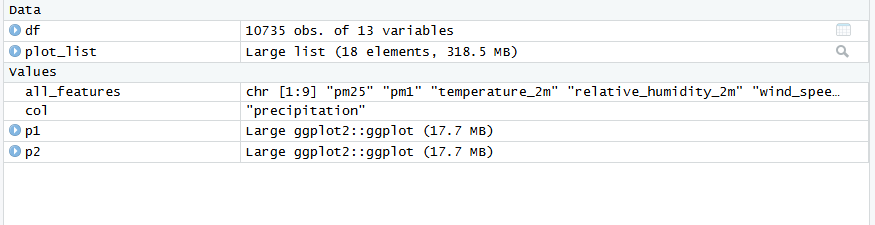

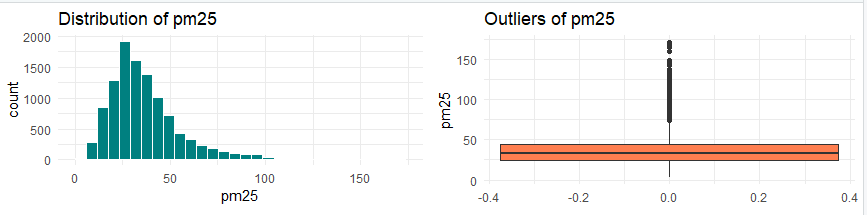

**Insight - PM2.5:**

- Phân phối của PM2.5 bị lệch phải rất mạnh (Right-skewed). Đỉnh của phân phối (Mode) tập trung ở dải giá trị thấp (25 µg/m3).
- Không được xóa (drop) các outliers này: Đây không phải là lỗi đo đạc (sensor error) mà phản ánh các sự kiện ô nhiễm cực đoan thực tế (ví dụ: giờ cao điểm kẹt xe, hiện tượng nghịch nhiệt).
- Đối với các mô hình nhạy cảm với phương sai và phân phối như ARIMA hay LSTM/GRU, bạn nên áp dụng phép biến đổi Logarit (Log Transformation - ví dụ np.log1p) hoặc Box-Cox để đưa phân phối về dạng gần chuẩn (Normal distribution) hơn.

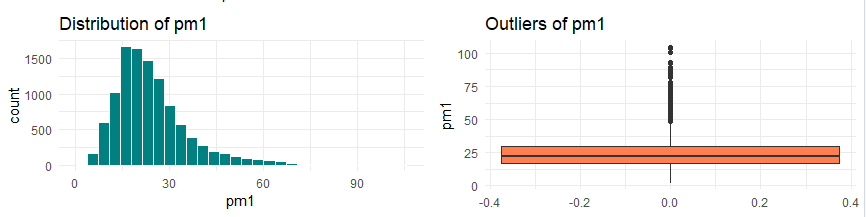

**Insight - PM1:**

- Hạt PM1 nhỏ hơn và nguy hiểm hơn. Nồng độ PM1 thường có sự tương quan tuyến tính rất chặt chẽ theo PM2.5.
- Phân phối của PM1 lệch phải rất mạnh (Right-skewed). Đỉnh (Mode) tập trung ở dải giá trị thấp (dưới 20 µg/m³).
- Lưu ý vì PM1 tương đồng cao với PM2.5 (có thể loại bỏ)

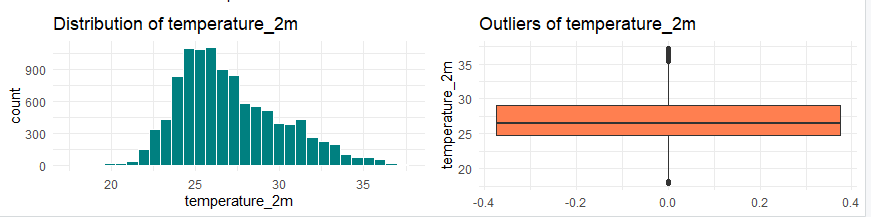

**Insight - UM003:**

- Thể hiện số lượng hạt PM siêu nhỏ trong không khí. Phân phối lệch phải.
- Không loại bỏ Outliers. Các giá trị chục ngàn này chính là những thời điểm ô nhiễm khói bụi nghiêm trọng nhất tại TP.HCM.
- Trục x của biến này trải dài từ 0 đến 14000 --> dùng Log Transformation (np.log1p) để đưa phân phối về dạng hình chuông, sau đó có thể ép về khoảng [0, 1] bằng MinMaxScaler.

# 3. Bivariate Analysis

Evaluating relationships between variables and temporal patterns.

In [ ]:
print("--- Đang thực hiện Bivariate với Regression Lines ---")
p_wind <- ggplot(df, aes(x = wind_speed_10m, y = pm25)) +
  geom_point(alpha = 0.2, color = "gray") +
  geom_smooth(method = "lm", color = "red") +
  labs(title = "PM2.5 vs Wind Speed", x = "Wind Speed (m/s)", y = "PM2.5") + theme_minimal()

p_humid <- ggplot(df, aes(x = relative_humidity_2m, y = pm25)) +
  geom_point(alpha = 0.2, color = "gray") +
  geom_smooth(method = "lm", color = "blue") +
  labs(title = "PM2.5 vs Humidity", x = "Humidity (%)", y = "PM2.5") + theme_minimal()

grid.arrange(p_wind, p_humid, ncol = 2)

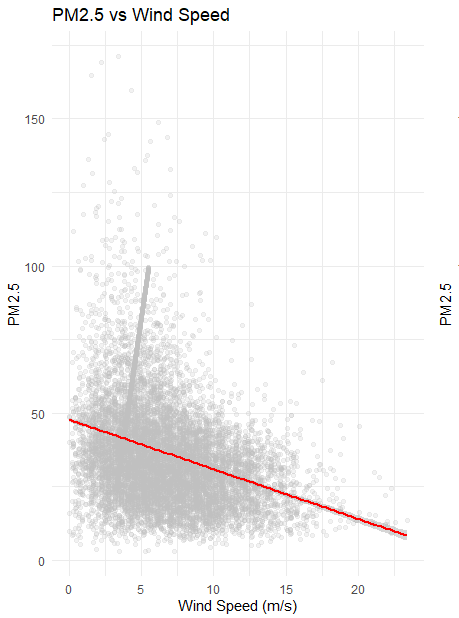

**Insight - PM2.5 vs Wind Speed:**

- Đường regplot cho thấy xu hướng chênh lệch giảm rõ rệt. Khi tốc độ gió tăng lên, quá trình pha loãng diễn ra mạnh, PM2.5 khó tụ lại một điểm. (Gió càng mạnh, PM2.5 càng giảm.)
- Tạo biến wind_condition: Stagnant (Đình trệ) nếu wind_speed < 5, Breeze (Gió nhẹ) nếu 5 <= wind_speed < 15, Windy (Có gió mạnh) nếu wind_speed >= 15

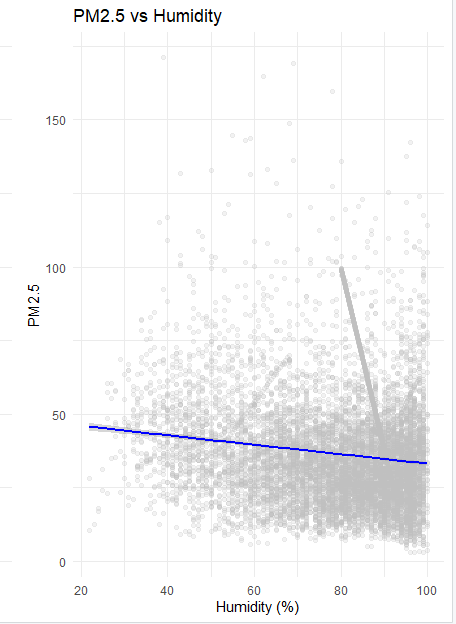

**Insight - PM2.5 vs RH:**

- Mối quan hệ phức tạp, có thể phi tuyến do độ ẩm quá cao/đạt mức mưa sương sẽ ngưng kết làm rơi PM2.5, nhưng khi ẩm vừa (không mưa) lại làm nổi hoặc tích tụ hạt...
- Có thể tạo một biến is_washout_condition. Bằng 1 nếu relative_humidity_2m > 95 VÀ precipitation > 0 (ngược lại bằng 0).

**Insight - Wind Direction Bins:**

- Giúp nhận diện được hướng vận chuyển nguồn phát ô nhiễm lân cận (vd: nhà máy nhiệt điện hướng Đông Nam v.v.) sẽ đẩy thẳng tới khu vực này.
- Nhóm ô nhiễm (Đông Nam, Nam, Đông): PM2.5 rất cao. Thường trùng với gió mùa khô, thổi khói bụi từ các khu công nghiệp (Đồng Nai, Bình Dương) và cảng Cát Lái vào trung tâm thành phố.
- Nhóm sạch (Tây, Tây Bắc, Bắc): PM2.5 thấp. Tương ứng với Gió mùa Tây Nam (mùa mưa), mang theo mưa rào giúp làm sạch không khí.
- Với XGBoost/LightGBM: Dùng One-Hot Encoding trực tiếp trên các bin (VD: is_wind_SE, is_wind_W).
- Với LSTM/SARIMAX: Mã hóa lượng giác thành 2 vector liên tục là U-wind và V-wind để mô hình toán học dễ học hơn.

# 4. Multivariate Analysis & Time-Series Component

In [ ]:

print("--- Phân tích Hướng gió bằng Boxplot ---")
# R có hàm cut cực mạnh để chia nhóm (Binning)
df$wind_dir_label <- cut(df$wind_direction_10m, 
                         breaks = seq(0, 360, by = 45),
                         labels = c("N", "NE", "E", "SE", "S", "SW", "W", "NW"),
                         include.lowest = TRUE)

ggplot(df, aes(x = wind_dir_label, y = pm25, fill = wind_dir_label)) +
  geom_boxplot() +
  scale_fill_viridis_d() +
  labs(title = "PM2.5 Distribution by Wind Direction", x = "Direction", y = "PM2.5") +
  theme_minimal() + theme(legend.position = "none")


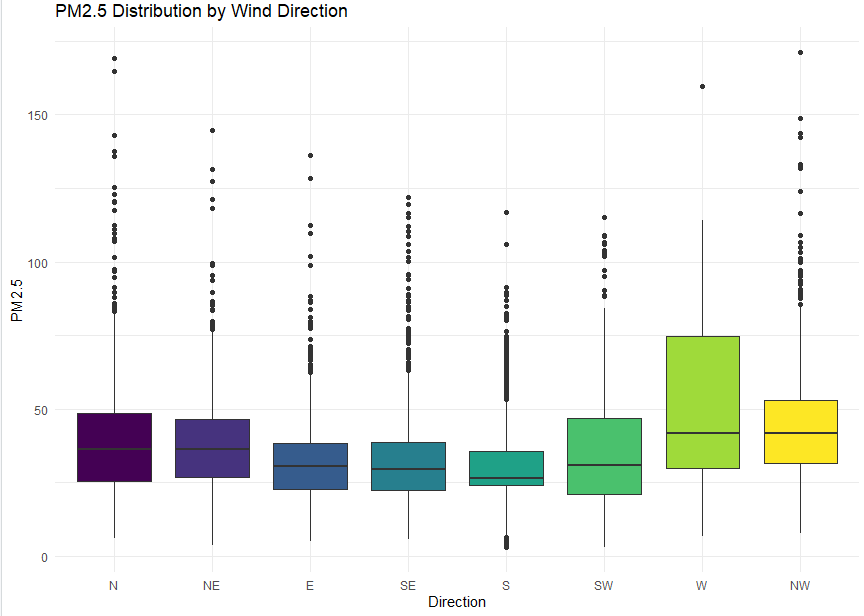

- Ô nhiễm nhất: Hướng W (Tây) và NW (Tây Bắc) — nồng độ PM2.5 cao và biến động mạnh nhất.
- Trong lành nhất: Hướng S (Nam) và SE (Đông Nam) — thường là gió biển/sông, giúp giảm bụi.
- Đột biến (Outliers): Hướng N (Bắc) và W (Tây) hay xuất hiện các đợt ô nhiễm cực nặng (vượt 150 $\mu g/m^3$

In [ ]:
print("--- Đang vẽ Pollution Rose (Sử dụng openair) ---")
#  openair yêu cầu cột tên 'ws' (wind speed) và 'wd' (wind direction)
df_rose <- df %>% rename(ws = wind_speed_10m, wd = wind_direction_10m, date = datetime_local)

pollutionRose(df_rose, pollutant = "pm25", 
              main = "HCMC Pollution Rose: PM2.5 & Wind Dynamics")


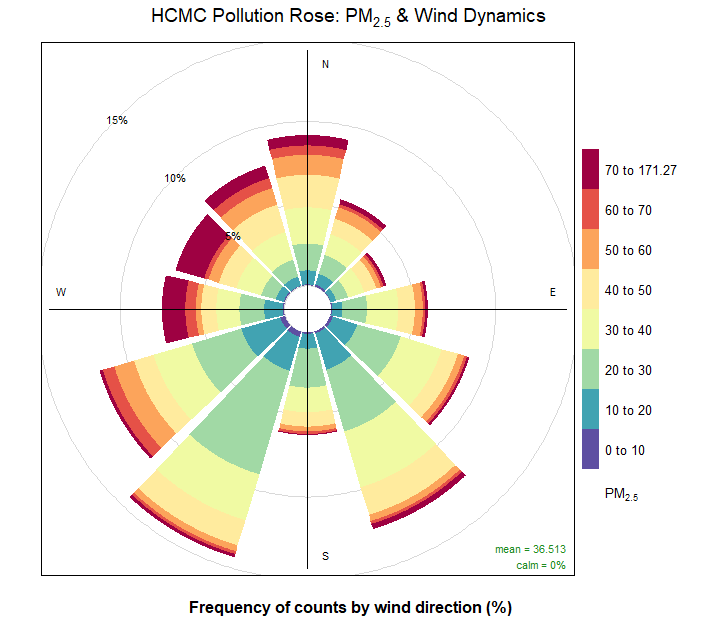

**Insight - Pollution Rose:**

- Biểu đồ này phối hợp cả 3 biến: PM2.5, Hướng Gió và Tần suất, cung cấp sự quan sát trực quan nhất những "cánh cung" (phương tiện/luồng gió) nào mang nhiều bụi tới TP.HCM nhất.
- Nhóm ô nhiễm (Đông Nam, Nam, Đông): PM2.5 rất cao. Thường trùng với gió mùa khô, thổi khói bụi từ các khu công nghiệp (Đồng Nai, Bình Dương) và cảng Cát Lái vào trung tâm thành phố.
- Nhóm sạch (Tây, Tây Bắc, Bắc): PM2.5 thấp. Tương ứng với Gió mùa Tây Nam (mùa mưa), mang theo mưa rào giúp làm sạch không khí.

In [ ]:

ts_pm25 <- ts(na.omit(df$pm25), frequency = 24)
Acf(ts_pm25, lag.max = 48, main = "PM2.5 Autocorrelation Decay (48h)")
abline(v = 24, col = "red", lty = 2) # Kẻ vạch 24h để làm Insight

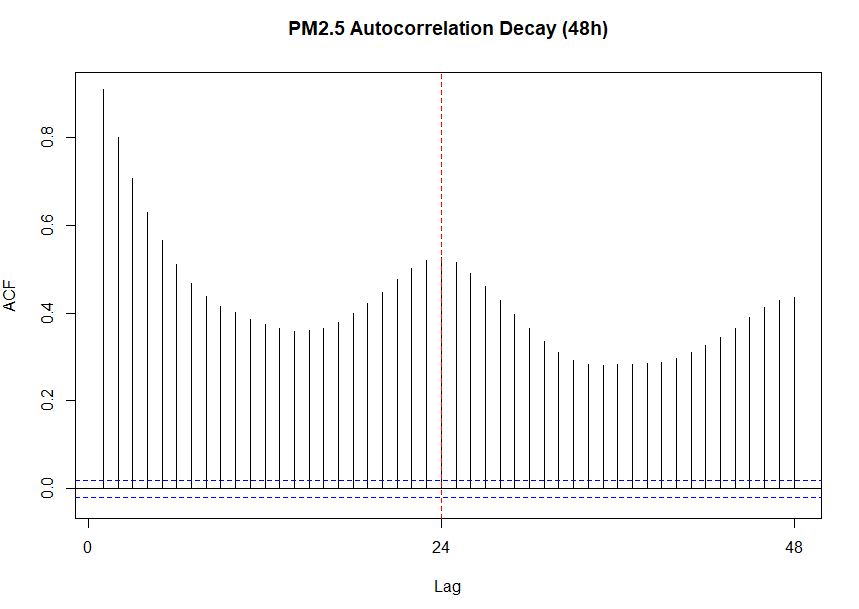

**Insight - ACF/PACF:**

- ACF (Hàm tự tương quan): Suy giảm rất chậm và có gợn sóng ở chu kỳ 24, 48. Chứng tỏ chuỗi PM2.5 không dừng (non-stationary) và có tính mùa vụ theo ngày (24h cycle). Bắt buộc phải lấy sai phân (
) nếu dùng họ mô hình ARIMA.
- PACF (Hàm tự tương quan riêng phần): Cắt đứt cực mạnh sau Lag 1 và Lag 2, có gai nhỏ ở Lag 24. Chứng tỏ nồng độ bụi hiện tại chỉ phụ thuộc trực tiếp vào 1-2 giờ liền trước và cùng giờ ngày hôm qua.
- Hành động (Feature Engineering): Cung cấp cơ sở toán học vững chắc để chốt danh sách biến trễ (Lag features): chỉ cần tạo PM2.5(t-1), PM2.5(t-2) và PM2.5(t-24) làm đầu vào cho Machine Learning/Deep Learning, giúp giảm chiều dữ liệu dư thừa.